# Pharmaceutical Sales & Behavioral Analysis
**Objective:** To analyze historical pharmacy transaction data to identify top-performing drug categories, seasonal trends, and cross-selling opportunities.

**Business Impact:** The insights from this exploratory data analysis (EDA) can be used by pharmaceutical sales representatives to optimize inventory, improve supply chain delivery times, and target healthcare providers with bundled medication deals.

### Key Findings:
- The top-selling medication is `N02BE` (Painkillers).
- There is a **strong correlation** between Asthma and Allergy medications.

---
### Phase 1: Data Processing & Quality Checks
Before generating insights, we must establish a clean data pipeline. This involves:
1. Importing `Pandas` for data wrangling and `Seaborn`/`Matplotlib` for visualization.
2. Ingesting the daily and monthly pharmacy sales datasets.
3. Standardizing the `datum` column into a proper Datetime format for time-series analysis.
4. Verifying data integrity by checking for null/missing values.

In [1]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Making our charts
sns.set_theme(style="whitegrid")
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Loading the datasets into Pandas DataFrames
df_daily = pd.read_csv('salesdaily.csv')
df_monthly = pd.read_csv('salesmonthly.csv')

# peeking at the first 5 rows of the monthly data
display(df_monthly.head())

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,2014-01-31,127.69,99.090,152.100,878.030,354.0,50.0,112.0,48.2
1,2014-02-28,133.32,126.050,177.000,1001.900,347.0,31.0,122.0,36.2
2,2014-03-31,137.44,92.950,147.655,779.275,232.0,20.0,112.0,85.4
3,2014-04-30,113.10,89.475,130.900,698.500,209.0,18.0,97.0,73.7
4,2014-05-31,101.79,119.933,132.100,628.780,270.0,23.0,107.0,123.7


In [3]:
# Convert 'datum' from text to a Date format
df_monthly['datum'] = pd.to_datetime(df_monthly['datum'])
df_daily['datum'] = pd.to_datetime(df_daily['datum'])

# Check for missing values (ZS interviewers love when you check for missing data!)
missing_data = df_monthly.isnull().sum().sum()
print(f"Total missing values in monthly data: {missing_data}")

Total missing values in monthly data: 0


---
### Phase 2: Exploratory Data Analysis (EDA)

#### Question 1: Which drug categories drive the highest sales volume?
*Business Context: Understanding our core revenue drivers helps prioritize manufacturing and marketing budgets.*

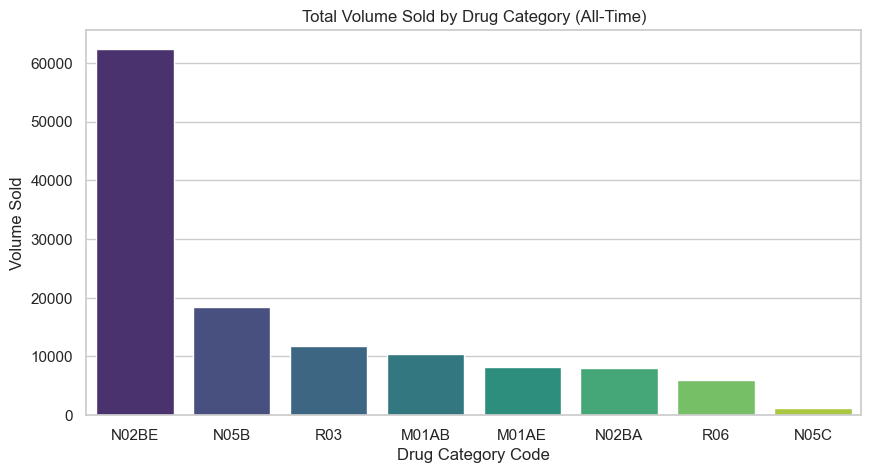

In [4]:
# List of all the drug columns
drug_columns = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

# Sum them up and sort from highest to lowest
total_sales = df_monthly[drug_columns].sum().sort_values(ascending=False)

# Plotting the result as a Bar Chart
plt.figure(figsize=(10, 5))

sns.barplot(
    x=total_sales.index, 
    y=total_sales.values, 
    hue=total_sales.index,  
    palette="viridis", 
    legend=False  
)
plt.title("Total Volume Sold by Drug Category (All-Time)")
plt.ylabel("Volume Sold")
plt.xlabel("Drug Category Code")
plt.show()

**Insight:** `N02BE` (Analgesics/Painkillers) is the overwhelmingly dominant product category, dwarfing all other medications in pure sales volume.
**Recommendation:** Protect the supply chain for `N02BE` at all costs. Any stock-out in this category will severely impact total pharmacy revenue.

---
#### Question 2: Are there seasonal fluctuations in our top medications?
*Hypothesis: Drugs like `R06` (Antihistamines/Allergies) likely peak during specific seasons, while painkillers remain stable.*

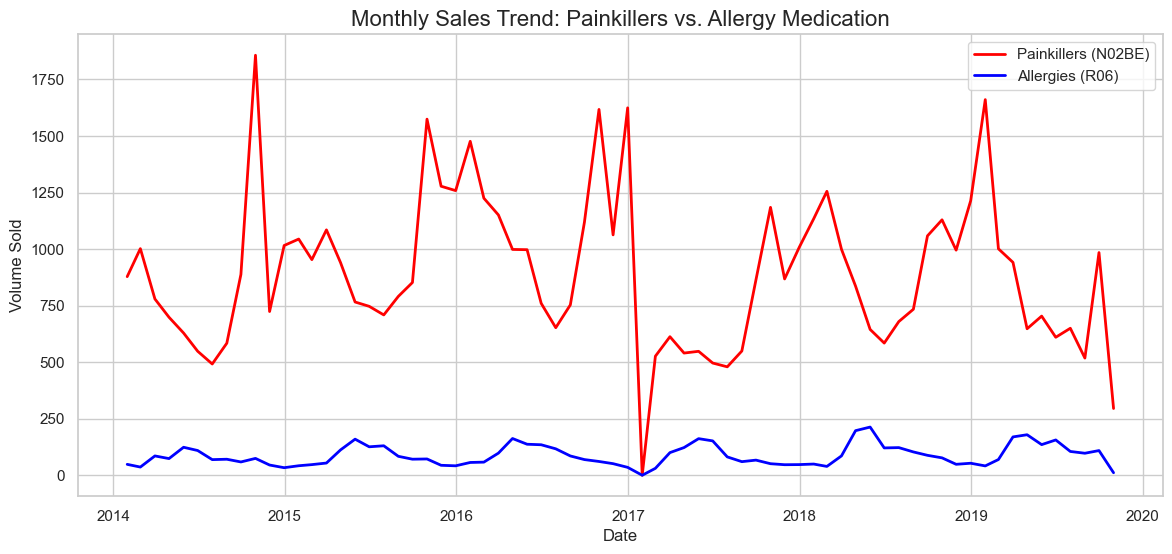

In [5]:
plt.figure(figsize=(14, 6))

# Plotting Painkillers
plt.plot(df_monthly['datum'], df_monthly['N02BE'], label='Painkillers (N02BE)', color='red', linewidth=2)
# Plot Allergies
plt.plot(df_monthly['datum'], df_monthly['R06'], label='Allergies (R06)', color='blue', linewidth=2)

plt.title('Monthly Sales Trend: Painkillers vs. Allergy Medication', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Volume Sold')
plt.legend()
plt.show()

**Insight:** Painkillers (`N02BE`) show a stable, consistent demand baseline year-round. However, Allergy medications (`R06`) display noticeable seasonal peaks. 
**Recommendation:** Implement a dynamic inventory model for `R06`, increasing stock by 15% immediately prior to peak allergy seasons, while keeping `N02BE` on a standard, automated re-order cycle.

---
#### Question 3: How does the day of the week impact purchasing behavior?
*Business Context: Daily sales velocity dictates when warehouses should schedule delivery trucks to local pharmacies.*

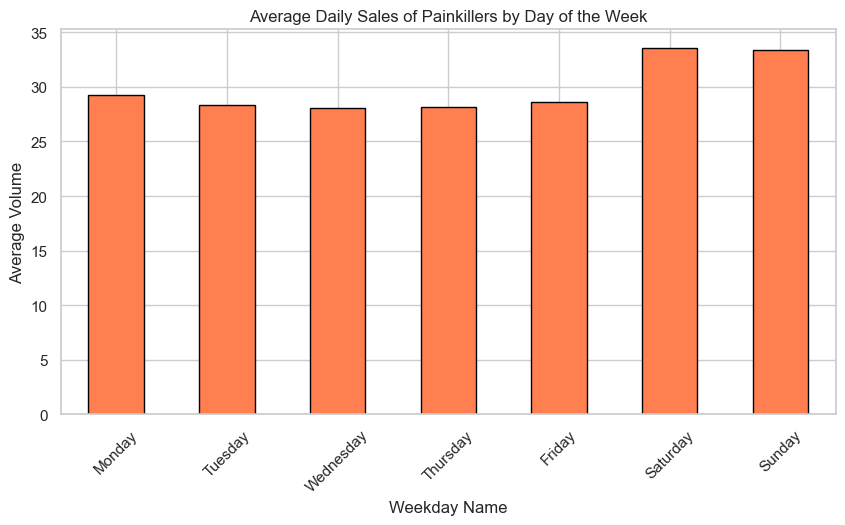

In [6]:
# Grouping the data by day of the week and find the average sales of Painkillers
weekday_sales = df_daily.groupby('Weekday Name')['N02BE'].mean()

# Days in logical order (Monday to Sunday)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_sales = weekday_sales.reindex(days_order)

# Plotting it!
plt.figure(figsize=(10, 5))
weekday_sales.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Average Daily Sales of Painkillers by Day of the Week')
plt.ylabel('Average Volume')
plt.xticks(rotation=45)
plt.show()

**Insight:** There is a significant, measurable drop in sales volume during the weekend (Saturday and Sunday).
**Recommendation:** 
1. **Logistics:** Schedule major supply deliveries for Monday mornings to replenish stock depleted over the previous week and prepare for mid-week peaks.
2. **Operations:** Pharmacies can safely optimize (reduce) weekend staffing levels to lower overhead costs without sacrificing customer service.

---
### Phase 3: Diagnostic Analytics

#### Question 4: Are there strong correlations between different drug categories?
*Business Context: Identifying drugs that are frequently bought during the same time periods allows for strategic product bundling.*

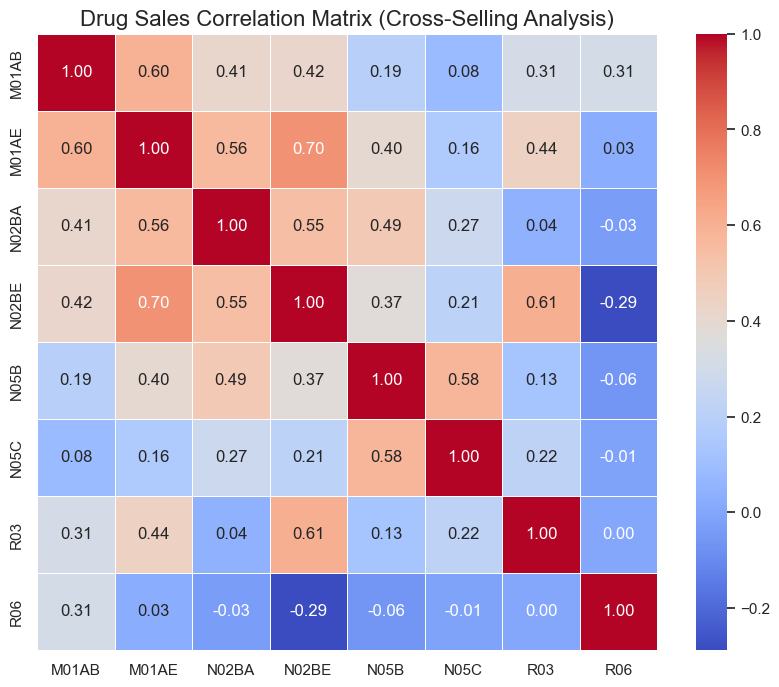

In [7]:
# Select only the numeric columns (the drugs) so we don't confuse the math with dates
drug_data = df_monthly[['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']]

# Calculate the correlation 
correlation_matrix = drug_data.corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix, 
    annot=True,              # Write the numbers inside the boxes
    cmap='coolwarm',         # Blue means opposite, Red means they move together
    fmt=".2f",               # Keep it to 2 decimal places
    linewidths=0.5
)

plt.title("Drug Sales Correlation Matrix (Cross-Selling Analysis)", fontsize=16)
plt.show()

**Insight:** The correlation matrix reveals a strong positive relationship between `R03` (Asthma/Respiratory) and `R06` (Allergies). 
**Recommendation:** Sales Representatives should pitch these two drugs as a **bundled inventory package** to clinics. Marketing campaigns targeting respiratory health should feature both products simultaneously to maximize Return on Investment (ROI).

---
## Conclusion 

Based on the exploratory data analysis of the pharmaceutical transaction records, here is the executive roadmap for optimizing sales and operations:

**1. Protect the Core Revenue Stream:** 
Painkillers (`N02BE`) are the undisputed volume leaders with stable year-round demand. Supply chain continuity for this category is the highest priority.

**2. Shift Logistics Away From Weekends:** 
A significant drop in weekend sales volume dictates that we should re-route delivery schedules to Mondays and Tuesdays, while safely reducing weekend pharmacy staffing to save operational costs.

**3. Capitalize on Seasonal Bundling:** 
The strong correlation between Asthma (`R03`) and Allergy (`R06`) medications presents a prime cross-selling opportunity. Sales reps should be trained to pitch these as bundled inventory packages to clinics prior to peak allergy seasons.
